# **intro to linear regression**

In [236]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, LinearRegression, Ridge, RidgeCV, LassoCV
from sklearn.model_selection import cross_val_score, GridSearchCV

## **import dataset**

In [237]:
df = pd.read_csv('../data/data.csv')
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


#### **shape of data** 

In [238]:
df.shape

(11914, 16)

#### **info of data** 

In [239]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

#### **check the number of missing data or null values in the data** 

In [240]:
df.isna().sum()

Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64

#### **descriptive statistics of data** 

In [241]:
df.describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


In [242]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

# turns the column names into lower case and replaces the space with underscores

In [243]:
df.head()

# views top five rows of the dataset

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [244]:
strings = list(df.dtypes[df.dtypes == "object"].index)
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [245]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [246]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


# **exploratory data analysis**

In [247]:
for col in df.columns:
    print(f"column name: {col}")
    print(f"Number of unique vaues: {df[col].nunique()}")
    print(df[col].unique()[:5])
    print()

column name: make
Number of unique vaues: 48
['bmw' 'audi' 'fiat' 'mercedes-benz' 'chrysler']

column name: model
Number of unique vaues: 914
['1_series_m' '1_series' '100' '124_spider' '190-class']

column name: year
Number of unique vaues: 28
[2011 2012 2013 1992 1993]

column name: engine_fuel_type
Number of unique vaues: 10
['premium_unleaded_(required)' 'regular_unleaded'
 'premium_unleaded_(recommended)' 'flex-fuel_(unleaded/e85)' 'diesel']

column name: engine_hp
Number of unique vaues: 356
[335. 300. 230. 320. 172.]

column name: engine_cylinders
Number of unique vaues: 9
[ 6.  4.  5.  8. 12.]

column name: transmission_type
Number of unique vaues: 5
['manual' 'automatic' 'automated_manual' 'direct_drive' 'unknown']

column name: driven_wheels
Number of unique vaues: 4
['rear_wheel_drive' 'front_wheel_drive' 'all_wheel_drive'
 'four_wheel_drive']

column name: number_of_doors
Number of unique vaues: 3
[ 2.  4.  3. nan]

column name: market_category
Number of unique vaues: 71
['

# **distribution of msrp(price of vehicles)**

<Axes: xlabel='msrp', ylabel='Count'>

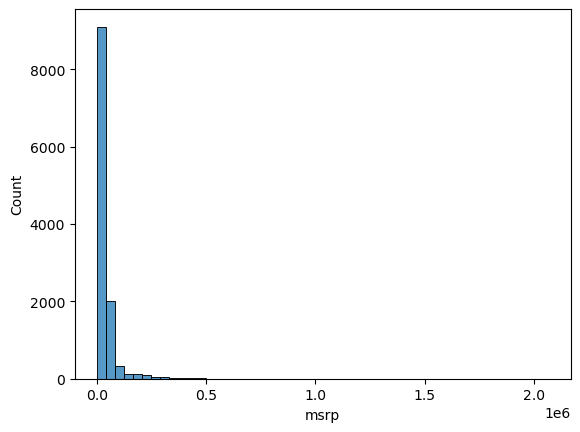

In [248]:
sns.histplot(df["msrp"], bins = 50)

## from histogram, the distribution is a right tail, right skewed
## less expensive cars occupy majority of the distribution
## meaning there are more less expensive cars than more expensive ones

#### **distribution of data with price less than 100000 is still skewed to the right** 
#### **there are more people with less expensive cars than more expensive ones** 

<Axes: xlabel='msrp', ylabel='Count'>

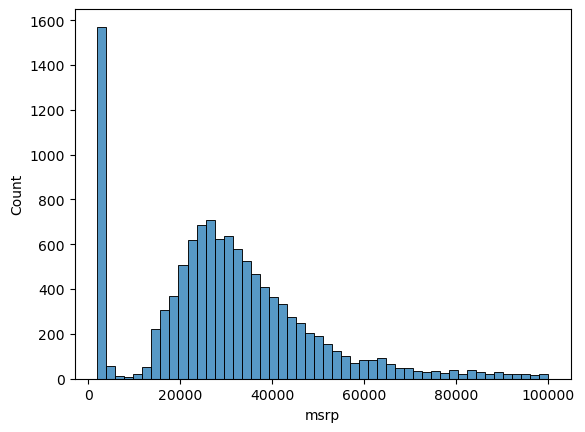

In [249]:
sns.histplot(df["msrp"][df["msrp"] < 100000], bins = 50)

#### **taking log of price, df["msrp"] to scale it down**

<Axes: xlabel='msrp', ylabel='Count'>

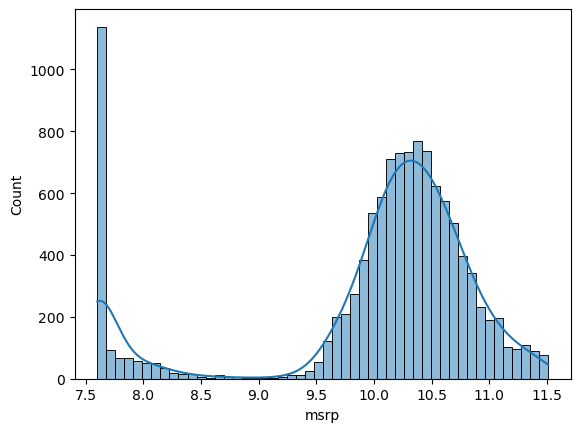

In [250]:
sns.histplot(
    np.log1p(df["msrp"][df["msrp"] < 100000]), 
    bins = 50,
    kde = True,
)


In [251]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

In [252]:
df_cp = df.copy()

In [253]:
df_cp = df_cp.fillna(0)

In [254]:
df_cp.isnull().sum()

make                 0
model                0
year                 0
engine_fuel_type     0
engine_hp            0
engine_cylinders     0
transmission_type    0
driven_wheels        0
number_of_doors      0
market_category      0
vehicle_size         0
vehicle_style        0
highway_mpg          0
city_mpg             0
popularity           0
msrp                 0
dtype: int64

## **setting up validating dataset**

In [284]:
df_cp["age"] = 2017 - df_cp['year']
df_cp.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp,age
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135,6
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650,6
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350,6
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450,6
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500,6


In [285]:
X = df_cp.drop(columns = "msrp")
y = np.log(df_cp["msrp"])

In [286]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size = 0.4,
    random_state = 24
    )

X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, 
    test_size = 0.5,
    random_state = 24
    )

print(df_cp.shape)
print(f"Train X: {X_train.shape}, Train y: {y_train.shape}" )
print(f"Temp X: {X_temp.shape}, Temp y: {y_temp.shape}" )
print(f"Test X: {X_test.shape}, Test y: {y_test.shape}" )
print(f"Val X: {X_val.shape}, val y: {y_val.shape}" )


(11914, 17)
Train X: (7148, 16), Train y: (7148,)
Temp X: (4766, 16), Temp y: (4766,)
Test X: (2383, 16), Test y: (2383,)
Val X: (2383, 16), val y: (2383,)


## **linear regression**

#### **first we will take out the categrical variables then model it then later we add the categorical variables and model it again**

In [287]:
X_train.isnull().sum()

make                 0
model                0
year                 0
engine_fuel_type     0
engine_hp            0
engine_cylinders     0
transmission_type    0
driven_wheels        0
number_of_doors      0
market_category      0
vehicle_size         0
vehicle_style        0
highway_mpg          0
city_mpg             0
popularity           0
age                  0
dtype: int64

In [288]:
lr = LinearRegression()

#### **training model with numeric columns except year and age using X_train**

In [289]:
X_train_num = X_train.select_dtypes(include = ["number"])
X_train_num.head()

,year,engine_hp,engine_cylinders,number_of_doors,highway_mpg,city_mpg,popularity,age
11217,2014,132.0,4.0,3.0,36,28,1439,3
11486,2016,228.0,4.0,4.0,32,22,3916,1
5797,2014,111.0,4.0,4.0,38,39,204,3
9337,2015,285.0,6.0,4.0,24,18,549,2
2287,2015,305.0,6.0,4.0,24,17,549,2


In [292]:
X_train_num.drop(columns = ["year", "age"]).head()

,engine_hp,engine_cylinders,number_of_doors,highway_mpg,city_mpg,popularity
11217,132.0,4.0,3.0,36,28,1439
11486,228.0,4.0,4.0,32,22,3916
5797,111.0,4.0,4.0,38,39,204
9337,285.0,6.0,4.0,24,18,549
2287,305.0,6.0,4.0,24,17,549


In [ ]:
lr.fit(X_train_num.drop(columns = ["year", "age"]), y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [293]:
y_train_pred = lr.predict(X_train_num.drop(columns = ["year", "age"]))
print(y_train_pred.shape)
print(y_train.shape)

(7148,)
(7148,)


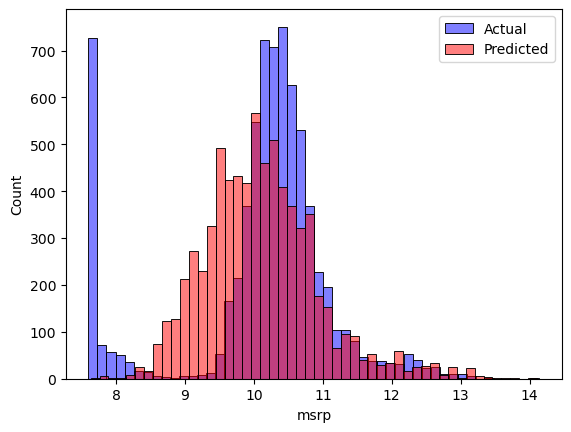

In [294]:
sns.histplot(y_train, color = "blue", bins = 50, alpha = 0.5, label = "Actual")
sns.histplot(y_train_pred, color = "red", bins = 50, alpha = 0.5, label = "Predicted")

plt.legend()
plt.show()


## **metrics**

In [295]:
def metrics(x, y):
    mse = np.sqrt(mean_squared_error(x, y))
    mape = mean_absolute_percentage_error(x, y)
    mae = mean_absolute_error(x, y)
    rsquare = r2_score(x, y)

    print(f"rmse: {mse}")
    print(f"mape: {mape}")
    print(f"mae: {mae}")
    print(f"r2: {rsquare}")

metrics(y_train, y_train_pred)

rmse: 0.7290851445414753
mape: 0.056927812827546595
mae: 0.5288929570345269
r2: 0.5641702555431058


#### **validating the model**

In [296]:
X_val_num = X_val.select_dtypes(include = ["number"])
X_val_num.head()

,year,engine_hp,engine_cylinders,number_of_doors,highway_mpg,city_mpg,popularity,age
9416,2002,185.0,6.0,4.0,22,16,26,15
6643,2007,425.0,8.0,4.0,18,13,1851,10
5628,2012,200.0,4.0,4.0,33,24,873,5
8204,1998,175.0,6.0,3.0,16,13,1851,19
9777,2016,138.0,4.0,4.0,34,27,1385,1


In [297]:
y_pred_val = lr.predict(X_val_num.drop(columns = ["year", "age"]))
print(f"y_pred_val shape: {y_pred_val.shape}")
print(f"y_val shape:{y_val.shape}")
    

y_pred_val shape: (2383,)
y_val shape:(2383,)


In [298]:
metrics(y_pred_val, y_val)

rmse: 0.7874043358199803
mape: 0.053390742732826804
mae: 0.5263159290550996
r2: 0.23426782313172323


#### **train model with year**

In [299]:
X_val.isnull().sum()


make                 0
model                0
year                 0
engine_fuel_type     0
engine_hp            0
engine_cylinders     0
transmission_type    0
driven_wheels        0
number_of_doors      0
market_category      0
vehicle_size         0
vehicle_style        0
highway_mpg          0
city_mpg             0
popularity           0
age                  0
dtype: int64

In [300]:
X_train.select_dtypes(include = ["number"]).drop(columns = "year").head()

,engine_hp,engine_cylinders,number_of_doors,highway_mpg,city_mpg,popularity,age
11217,132.0,4.0,3.0,36,28,1439,3
11486,228.0,4.0,4.0,32,22,3916,1
5797,111.0,4.0,4.0,38,39,204,3
9337,285.0,6.0,4.0,24,18,549,2
2287,305.0,6.0,4.0,24,17,549,2


In [301]:
print(X_val.shape)
print(y_val.shape)

(2383, 16)
(2383,)


In [302]:
X_val.select_dtypes(include = ["number"]).drop(columns = "year").head()

,engine_hp,engine_cylinders,number_of_doors,highway_mpg,city_mpg,popularity,age
9416,185.0,6.0,4.0,22,16,26,15
6643,425.0,8.0,4.0,18,13,1851,10
5628,200.0,4.0,4.0,33,24,873,5
8204,175.0,6.0,3.0,16,13,1851,19
9777,138.0,4.0,4.0,34,27,1385,1


In [ ]:
C:\Users\emman\Documents\DATA SCIENCE\AI_ML\machine_learning_zoomcamp\regression\linear_regression.ipynb

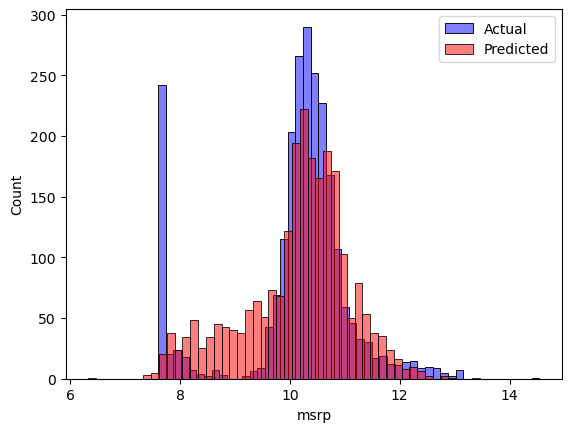

In [303]:
lr_model = lr.fit(
    X_train.select_dtypes(include = ["number"]).drop(columns = "year"),
    y_train
)

y_val_pred = lr_model.predict(
    X_val.select_dtypes(include = ["number"]).drop(columns = "year")
)
sns.histplot(y_val, color = "blue", bins = 50, alpha = 0.5, label = "Actual")
sns.histplot(y_val_pred, color = "red", bins = 50, alpha = 0.5, label = "Predicted")

plt.legend()
plt.show()

## **metrics**

In [304]:
metrics(y_val, y_val_pred)

rmse: 0.5166315074194096
mape: 0.039930309672716664
mae: 0.3891105295431961
r2: 0.779976928037473
